In [1]:
import disk_ecc as original
import disk_ecc_warp_setstructure as mine

import numpy as np
import bettermoments as bm

import matplotlib.pyplot as plt

In [2]:
def matrix_mine(x, y, z, warp, twist, inc_, PA_):

    warp = warp[None, :, None]
    #print("warp.shape" + str(warp.shape))
    twist = twist[None, :, None]
    #print("twist.shape" + str(twist.shape))

    cosw = np.cos(warp)
    sinw = np.sin(warp)
    

    cost = np.cos(twist)
    sint = np.sin(twist)

    cosPA = np.cos(PA_)
    sinPA = np.sin(PA_)

    cosi = np.cos(inc_)
    sini = np.sin(inc_)

    '''making sure twist occurs before warp'''

    #x_t = x*cost + y*(-sint)
    #y_t = x*sint + y*cost

    #xp = x_t
    #yp = y_t*cosw + z*(-sinw)
    #zp = y_t*sinw + z*cosw

    #xp = x*(-sinPA*sint*cosi + cosPA*cost)+ y*((-sinPA*cosi*cost - sint*cosPA)


    xp = x*(-sinPA*sint*cosi + cosPA*cost) + y*((-sinPA*cosi*cost - sint*cosPA)*cosw + sinPA*sini*sinw) + z*(-(-sinPA*cosi*cost - sint*cosPA)*sinw + sinPA*sini*cosw)
    yp = x*(sinPA*cost + sint*cosPA*cosi) + y*((-sinPA*sint + cosPA*cosi*cost)*cosw - sini*sinw*cosPA) + z*(-(-sinPA*sint + cosPA*cosi*cost)*sinw - sini*cosPA*cosw)
    zp = y*(sini*cost*cosw + sinw*cosi) + z*(-sini*sinw*cost + cosi*cosw)

    return xp, yp, zp


In [3]:
r = np.linspace(0, 100, 100)
phi = np.linspace(0, np.pi*2, 80)
z = np.linspace(-25, 25, 50)

R, Phi, Z = np.meshgrid(r, phi, z)

In [4]:
R[:,1,:]

array([[1.01010101, 1.01010101, 1.01010101, ..., 1.01010101, 1.01010101,
        1.01010101],
       [1.01010101, 1.01010101, 1.01010101, ..., 1.01010101, 1.01010101,
        1.01010101],
       [1.01010101, 1.01010101, 1.01010101, ..., 1.01010101, 1.01010101,
        1.01010101],
       ...,
       [1.01010101, 1.01010101, 1.01010101, ..., 1.01010101, 1.01010101,
        1.01010101],
       [1.01010101, 1.01010101, 1.01010101, ..., 1.01010101, 1.01010101,
        1.01010101],
       [1.01010101, 1.01010101, 1.01010101, ..., 1.01010101, 1.01010101,
        1.01010101]])

In [5]:
#xl = np.linspace (-100, 100, 100)
#yl = np.linspace (-100, 100, 100)
#zl = np.linspace (-100, 100, 50)

#X, Y, Z = np.meshgrid(xl, yl, zl)


In [6]:
def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(rho, phi)

def pol2cart(rho, phi):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return(x, y)

In [7]:
def w_func_sky(r0, dr, a_in, a_out, r):
    #r0 = self.w_r0
    #dr = self.w_dr
    '''
    if type == "w":
        a_in = self.w_i
        a_out = self.inc
        print("a_out " + str(a_out))
        print("a_in" + str(a_in))

    elif type == "pa":
        a_in = self.pa
        a_out = self.pos
        print("a_out " + str(a_out))
        print("a_in" + str(a_in))
    '''
    r0 = 1.0 if r0 is None else r0
    dr = 1.0 if dr is None else dr

    exp  = np.radians(a_out - (a_out - a_in) / (1 + np.exp((r - r0)/(0.1 * dr))))
    return exp

In [8]:
inc = 89/2
incl = np.deg2rad(inc)
az =0
azi = np.deg2rad(az)
r0 = 55
dr = 10
w_i = 89/2
w_pa = 70

In [9]:
#R, Phi = cart2pol(X,Y)
X, Y = pol2cart(R, Phi)

twist = w_func_sky(r0, dr, w_pa, az, r)
warp = w_func_sky(r0, dr, w_i, inc, r)

X_w, Y_w, Z_w = matrix_mine(X, Y, Z, warp, twist, incl, azi)

In [10]:
X.shape

(80, 100, 50)

In [11]:
X_w.shape

(80, 100, 50)

(-100.0, 100.0)

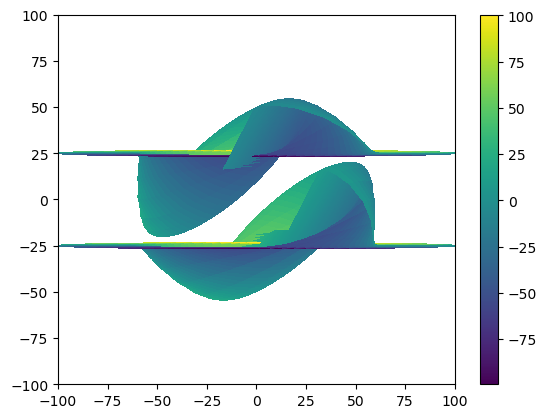

In [12]:
plt.pcolor(X_w[:,:,0], Y_w[:,:,0], Z_w[:,:,0])
plt.pcolor(X_w[:,:,-1], Y_w[:,:,-1], Z_w[:,:,-1])
plt.colorbar()
plt.xlim(-100,100)
plt.ylim(-100,100)

In [13]:
import sympy as sp

In [14]:
def Rx(angle):
    return sp.Matrix([
    [1,       0,              0],
    [0,       sp.cos(angle), -sp.sin(angle)],
    [0,       sp.sin(angle),  sp.cos(angle)],
])

def Ry(angle):
    return sp.Matrix([
    [ sp.cos(angle), 0, sp.sin(angle)],
    [0,              1, 0],
    [-sp.sin(angle), 0, sp.cos(angle)],
])

def Rz(angle):
    return sp.Matrix([
    [sp.cos(angle), -sp.sin(angle), 0],
    [sp.sin(angle),  sp.cos(angle), 0],
    [0,              0,             1],
])

In [304]:
### Working this through step by step. Starting with twist
#rotation around z-axis for a face-on disk. 


def matrix_twist(x, y, z, warp, twist, inc_, PA_):

    warp = warp[None, :, None]
    twist = twist[None, :, None]

    cosPA = np.cos(PA_)
    sinPA = np.sin(PA_)
    
    cosi = np.cos(inc_)
    sini = np.sin(inc_)

    '''making sure twist occurs before warp'''

    cosw = np.cos(warp)
    sinw = np.sin(warp)

    cost = np.cos(twist)
    sint = np.sin(twist)
    
    y_w = y*cosw - z*sinw
    z_w = y*sinw + z*cosw
    
    x_t = x*cost - y_w*sint
    y_t = x*sint + y_w*cost

    x_pa = x_t*cosPA - y_t*sinPA
    y_pa = x_t*sinPA + y_t*cosPA
    
    y_f = y_pa*cosi - z_w*sini
    z_f = y_pa*sini + z_w*cosi


    return x_pa, y_f, z_f


In [330]:
inc = 89
incl = np.deg2rad(inc)
az =0
azi = np.deg2rad(az)
r0 = 50
dr = 20
w_i = 20
w_pa = 0

twist = w_func_sky(r0, dr, w_pa, 0, r)
warp = w_func_sky(r0, dr, w_i, 0, r)

In [331]:
X_t, Y_t, Z_t = matrix_twist(X, Y, Z, warp, twist, incl, azi)

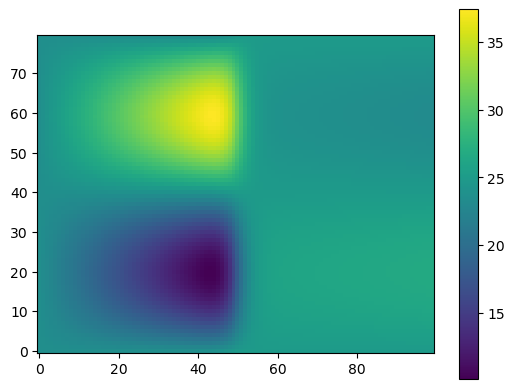

In [332]:
plt.imshow(Y_t[:,:,0], origin="lower")
plt.colorbar()

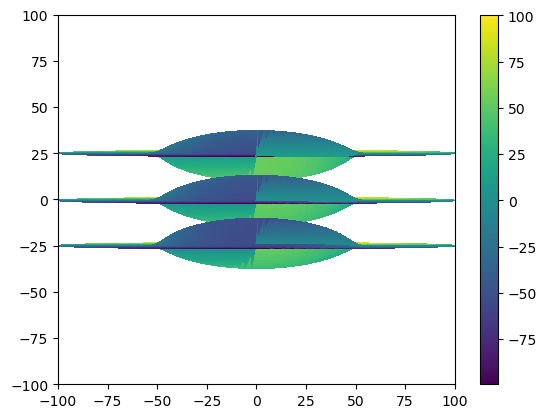

In [333]:
plt.pcolor(X_t[:,:,0], Y_t[:,:,0], Z_t[:,:,0])
plt.pcolor(X_t[:,:,25], Y_t[:,:,25], Z_t[:,:,25])
plt.pcolor(X_t[:,:,-1], Y_t[:,:,-1], Z_t[:,:,-1])
#plt.plot(X_t[:,:,0], Y_t[:,:,0])
plt.xlim(-100,100)
plt.ylim(-100,100)

plt.colorbar()

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]]]


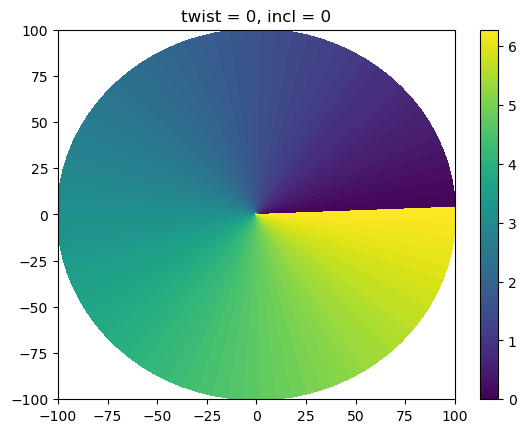

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020142e-01]
  [3.42020141e-01]
  [3.42020140e-01]
  [3.42020138e-01]
  [3.42020134e-01]
  [3.42020129e-01]
  [3.42020119e-01]
  [3.42020103e-01]
  [3.42020076e-01]
  [3.42020032e-01]
  [3.42019959e-01]
  [3.42019839e-01]
  [3.42019638e-01]
  [3.42019306e-01]
  [3.42018756e-01]
  [3.42017845e-01]
  [3.42016335e-01]
  [3.42013833e-01]
  [3.42009687e-01]
  [3.42002816e-01]
  [3.41991432e-01]
  [3.41972569e-01]
  [3.41941316e-01]
  [3.41889541e-01]
  [3.41803779e-01]
  [3.41661758e-01]
  [3.41426674e-01]
  [3.41037817e-01]
  [3.40395355e-01]
  [3.39335940e-01]
  [3.37594530e-01]
  [3.34747033e-01]
  [3.30130557e-01]
  [3.22749123e-01]
  [3.11204926e-01]
  [2.93762901e-01]
  [2.68744273e-01]
  [2.35422745e-01]
  [1.95

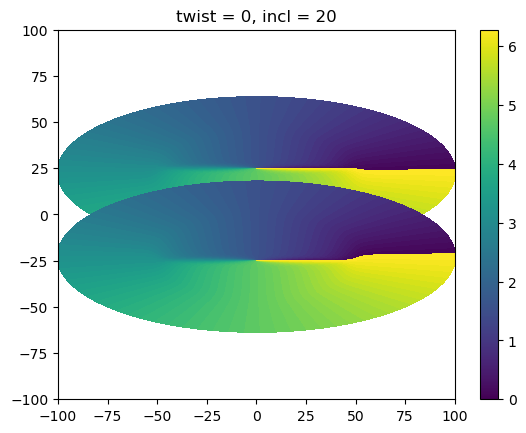

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787608e-01]
  [6.42787607e-01]
  [6.42787604e-01]
  [6.42787601e-01]
  [6.42787595e-01]
  [6.42787586e-01]
  [6.42787570e-01]
  [6.42787544e-01]
  [6.42787500e-01]
  [6.42787429e-01]
  [6.42787310e-01]
  [6.42787113e-01]
  [6.42786786e-01]
  [6.42786245e-01]
  [6.42785348e-01]
  [6.42783863e-01]
  [6.42781401e-01]
  [6.42777321e-01]
  [6.42770561e-01]
  [6.42759359e-01]
  [6.42740797e-01]
  [6.42710041e-01]
  [6.42659082e-01]
  [6.42574654e-01]
  [6.42434793e-01]
  [6.42203147e-01]
  [6.41819606e-01]
  [6.41184911e-01]
  [6.40135526e-01]
  [6.38403057e-01]
  [6.35549811e-01]
  [6.30869635e-01]
  [6.23243761e-01]
  [6.10954117e-01]
  [5.91502739e-01]
  [5.61603175e-01]
  [5.17715183e-01]
  [4.57611467e-01]
  [3.82

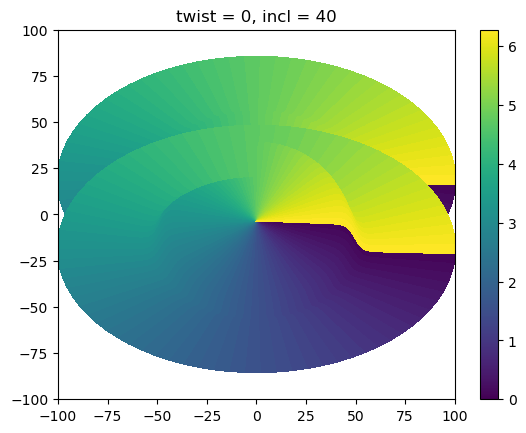

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025402e-01]
  [8.66025401e-01]
  [8.66025399e-01]
  [8.66025395e-01]
  [8.66025390e-01]
  [8.66025380e-01]
  [8.66025365e-01]
  [8.66025339e-01]
  [8.66025297e-01]
  [8.66025227e-01]
  [8.66025110e-01]
  [8.66024917e-01]
  [8.66024598e-01]
  [8.66024068e-01]
  [8.66023190e-01]
  [8.66021735e-01]
  [8.66019325e-01]
  [8.66015330e-01]
  [8.66008712e-01]
  [8.65997744e-01]
  [8.65979569e-01]
  [8.65949453e-01]
  [8.65899549e-01]
  [8.65816858e-01]
  [8.65679837e-01]
  [8.65452799e-01]
  [8.65076623e-01]
  [8.64453392e-01]
  [8.63420990e-01]
  [8.61711207e-01]
  [8.58880906e-01]
  [8.54200013e-01]
  [8.46472992e-01]
  [8.33768143e-01]
  [8.13055849e-01]
  [7.79885696e-01]
  [7.28594229e-01]
  [6.54076078e-01]
  [5.55

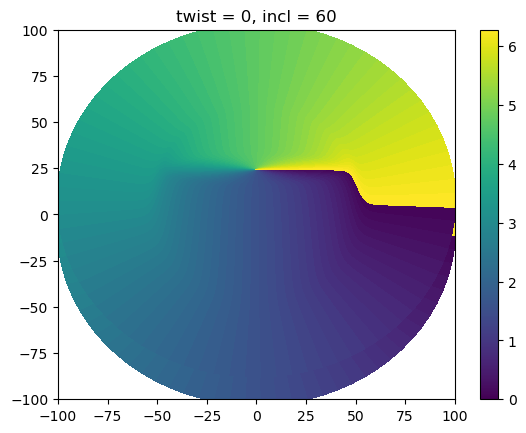

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807751e-01]
  [9.84807749e-01]
  [9.84807746e-01]
  [9.84807742e-01]
  [9.84807735e-01]
  [9.84807723e-01]
  [9.84807703e-01]
  [9.84807671e-01]
  [9.84807617e-01]
  [9.84807528e-01]
  [9.84807380e-01]
  [9.84807134e-01]
  [9.84806728e-01]
  [9.84806054e-01]
  [9.84804938e-01]
  [9.84803088e-01]
  [9.84800023e-01]
  [9.84794943e-01]
  [9.84786523e-01]
  [9.84772568e-01]
  [9.84749432e-01]
  [9.84711066e-01]
  [9.84647412e-01]
  [9.84541718e-01]
  [9.84365987e-01]
  [9.84073180e-01]
  [9.83583605e-01]
  [9.82760525e-01]
  [9.81365005e-01]
  [9.78969428e-01]
  [9.74787683e-01]
  [9.67343213e-01]
  [9.53860853e-01]
  [9.29348478e-01]
  [8.85865588e-01]
  [8.13772543e-01]
  [7.07

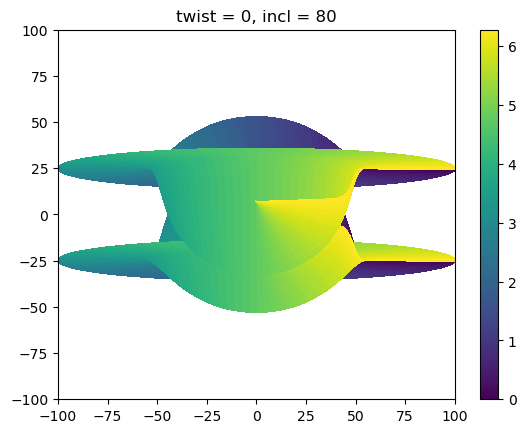

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [9.99999999e-01]
  [9.99999997e-01]
  [9.99999991e-01]
  [9.99999974e-01]
  [9.99999929e-01]
  [9.99999804e-01]
  [9.99999463e-01]
  [9.99998527e-01]
  [9.99995962e-01]
  [9.99988940e-01]
  [9.99969749e-01]
  [9.99917473e-01]
  [9.99775811e-01]
  [9.99395206e-01]
  [9.98386868e-01]
  [9.95775618e-01]
  [9.89255421e-01]
  [9.73877639e-01]
  [9.40602635e-01]
  [8.76931893e-01]
  [7.73

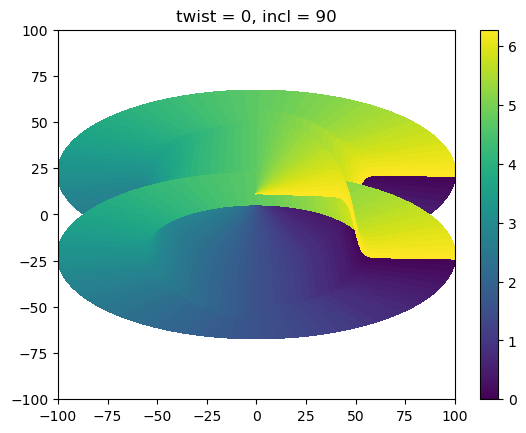

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]]]


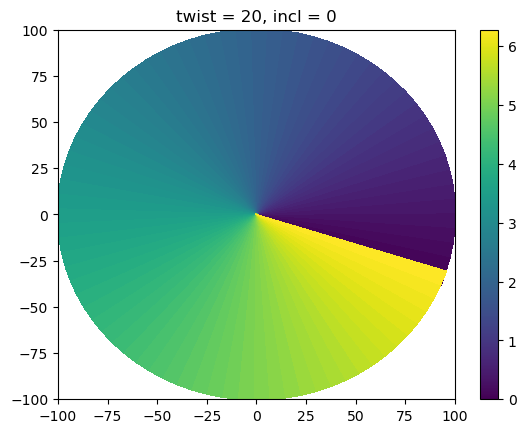

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020142e-01]
  [3.42020141e-01]
  [3.42020140e-01]
  [3.42020138e-01]
  [3.42020134e-01]
  [3.42020129e-01]
  [3.42020119e-01]
  [3.42020103e-01]
  [3.42020076e-01]
  [3.42020032e-01]
  [3.42019959e-01]
  [3.42019839e-01]
  [3.42019638e-01]
  [3.42019306e-01]
  [3.42018756e-01]
  [3.42017845e-01]
  [3.42016335e-01]
  [3.42013833e-01]
  [3.42009687e-01]
  [3.42002816e-01]
  [3.41991432e-01]
  [3.41972569e-01]
  [3.41941316e-01]
  [3.41889541e-01]
  [3.41803779e-01]
  [3.41661758e-01]
  [3.41426674e-01]
  [3.41037817e-01]
  [3.40395355e-01]
  [3.39335940e-01]
  [3.37594530e-01]
  [3.34747033e-01]
  [3.30130557e-01]
  [3.22749123e-01]
  [3.11204926e-01]
  [2.93762901e-01]
  [2.68744273e-01]
  [2.35422745e-01]
  [1.95

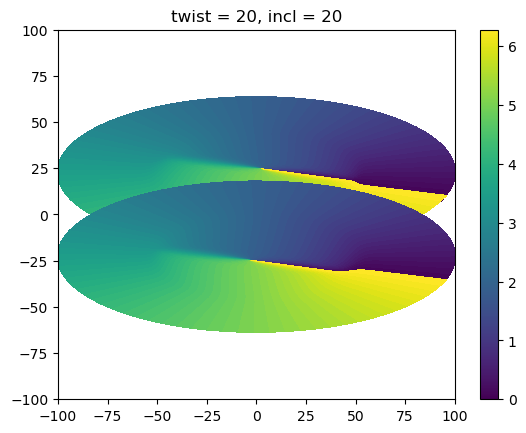

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787608e-01]
  [6.42787607e-01]
  [6.42787604e-01]
  [6.42787601e-01]
  [6.42787595e-01]
  [6.42787586e-01]
  [6.42787570e-01]
  [6.42787544e-01]
  [6.42787500e-01]
  [6.42787429e-01]
  [6.42787310e-01]
  [6.42787113e-01]
  [6.42786786e-01]
  [6.42786245e-01]
  [6.42785348e-01]
  [6.42783863e-01]
  [6.42781401e-01]
  [6.42777321e-01]
  [6.42770561e-01]
  [6.42759359e-01]
  [6.42740797e-01]
  [6.42710041e-01]
  [6.42659082e-01]
  [6.42574654e-01]
  [6.42434793e-01]
  [6.42203147e-01]
  [6.41819606e-01]
  [6.41184911e-01]
  [6.40135526e-01]
  [6.38403057e-01]
  [6.35549811e-01]
  [6.30869635e-01]
  [6.23243761e-01]
  [6.10954117e-01]
  [5.91502739e-01]
  [5.61603175e-01]
  [5.17715183e-01]
  [4.57611467e-01]
  [3.82

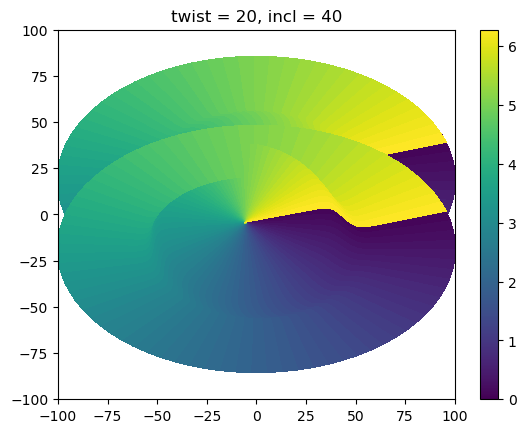

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025402e-01]
  [8.66025401e-01]
  [8.66025399e-01]
  [8.66025395e-01]
  [8.66025390e-01]
  [8.66025380e-01]
  [8.66025365e-01]
  [8.66025339e-01]
  [8.66025297e-01]
  [8.66025227e-01]
  [8.66025110e-01]
  [8.66024917e-01]
  [8.66024598e-01]
  [8.66024068e-01]
  [8.66023190e-01]
  [8.66021735e-01]
  [8.66019325e-01]
  [8.66015330e-01]
  [8.66008712e-01]
  [8.65997744e-01]
  [8.65979569e-01]
  [8.65949453e-01]
  [8.65899549e-01]
  [8.65816858e-01]
  [8.65679837e-01]
  [8.65452799e-01]
  [8.65076623e-01]
  [8.64453392e-01]
  [8.63420990e-01]
  [8.61711207e-01]
  [8.58880906e-01]
  [8.54200013e-01]
  [8.46472992e-01]
  [8.33768143e-01]
  [8.13055849e-01]
  [7.79885696e-01]
  [7.28594229e-01]
  [6.54076078e-01]
  [5.55

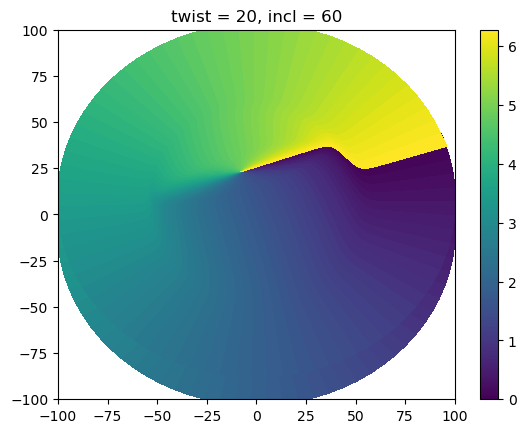

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807751e-01]
  [9.84807749e-01]
  [9.84807746e-01]
  [9.84807742e-01]
  [9.84807735e-01]
  [9.84807723e-01]
  [9.84807703e-01]
  [9.84807671e-01]
  [9.84807617e-01]
  [9.84807528e-01]
  [9.84807380e-01]
  [9.84807134e-01]
  [9.84806728e-01]
  [9.84806054e-01]
  [9.84804938e-01]
  [9.84803088e-01]
  [9.84800023e-01]
  [9.84794943e-01]
  [9.84786523e-01]
  [9.84772568e-01]
  [9.84749432e-01]
  [9.84711066e-01]
  [9.84647412e-01]
  [9.84541718e-01]
  [9.84365987e-01]
  [9.84073180e-01]
  [9.83583605e-01]
  [9.82760525e-01]
  [9.81365005e-01]
  [9.78969428e-01]
  [9.74787683e-01]
  [9.67343213e-01]
  [9.53860853e-01]
  [9.29348478e-01]
  [8.85865588e-01]
  [8.13772543e-01]
  [7.07

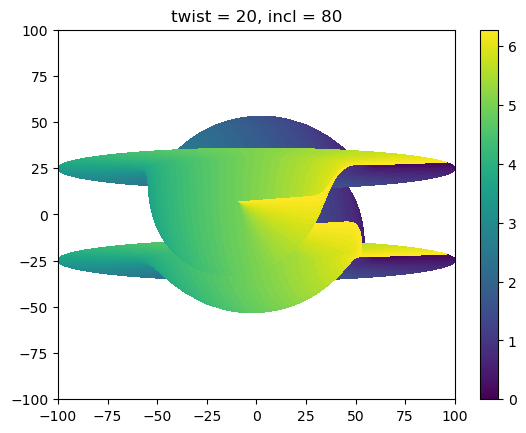

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [9.99999999e-01]
  [9.99999997e-01]
  [9.99999991e-01]
  [9.99999974e-01]
  [9.99999929e-01]
  [9.99999804e-01]
  [9.99999463e-01]
  [9.99998527e-01]
  [9.99995962e-01]
  [9.99988940e-01]
  [9.99969749e-01]
  [9.99917473e-01]
  [9.99775811e-01]
  [9.99395206e-01]
  [9.98386868e-01]
  [9.95775618e-01]
  [9.89255421e-01]
  [9.73877639e-01]
  [9.40602635e-01]
  [8.76931893e-01]
  [7.73

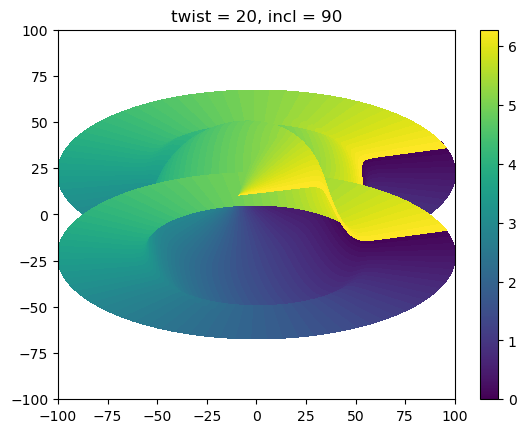

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]]]


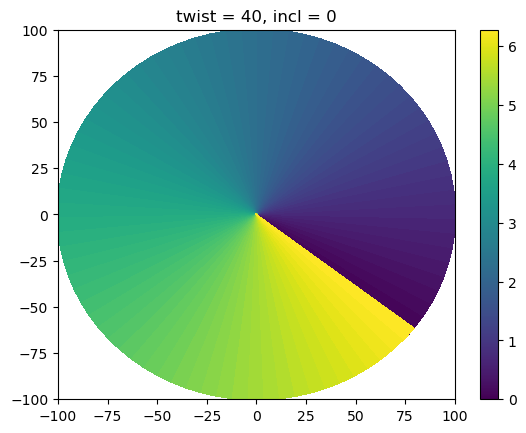

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020142e-01]
  [3.42020141e-01]
  [3.42020140e-01]
  [3.42020138e-01]
  [3.42020134e-01]
  [3.42020129e-01]
  [3.42020119e-01]
  [3.42020103e-01]
  [3.42020076e-01]
  [3.42020032e-01]
  [3.42019959e-01]
  [3.42019839e-01]
  [3.42019638e-01]
  [3.42019306e-01]
  [3.42018756e-01]
  [3.42017845e-01]
  [3.42016335e-01]
  [3.42013833e-01]
  [3.42009687e-01]
  [3.42002816e-01]
  [3.41991432e-01]
  [3.41972569e-01]
  [3.41941316e-01]
  [3.41889541e-01]
  [3.41803779e-01]
  [3.41661758e-01]
  [3.41426674e-01]
  [3.41037817e-01]
  [3.40395355e-01]
  [3.39335940e-01]
  [3.37594530e-01]
  [3.34747033e-01]
  [3.30130557e-01]
  [3.22749123e-01]
  [3.11204926e-01]
  [2.93762901e-01]
  [2.68744273e-01]
  [2.35422745e-01]
  [1.95

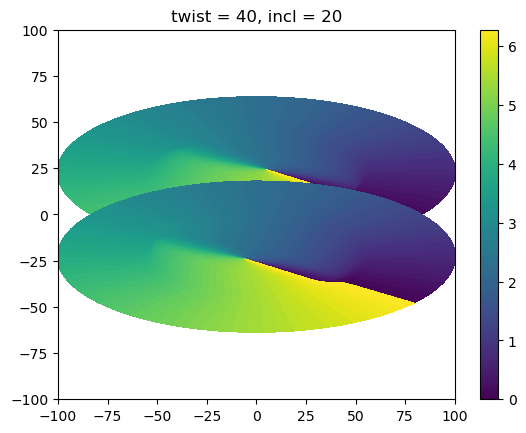

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787608e-01]
  [6.42787607e-01]
  [6.42787604e-01]
  [6.42787601e-01]
  [6.42787595e-01]
  [6.42787586e-01]
  [6.42787570e-01]
  [6.42787544e-01]
  [6.42787500e-01]
  [6.42787429e-01]
  [6.42787310e-01]
  [6.42787113e-01]
  [6.42786786e-01]
  [6.42786245e-01]
  [6.42785348e-01]
  [6.42783863e-01]
  [6.42781401e-01]
  [6.42777321e-01]
  [6.42770561e-01]
  [6.42759359e-01]
  [6.42740797e-01]
  [6.42710041e-01]
  [6.42659082e-01]
  [6.42574654e-01]
  [6.42434793e-01]
  [6.42203147e-01]
  [6.41819606e-01]
  [6.41184911e-01]
  [6.40135526e-01]
  [6.38403057e-01]
  [6.35549811e-01]
  [6.30869635e-01]
  [6.23243761e-01]
  [6.10954117e-01]
  [5.91502739e-01]
  [5.61603175e-01]
  [5.17715183e-01]
  [4.57611467e-01]
  [3.82

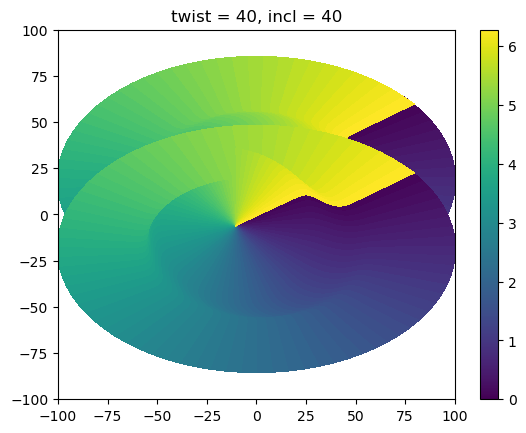

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025402e-01]
  [8.66025401e-01]
  [8.66025399e-01]
  [8.66025395e-01]
  [8.66025390e-01]
  [8.66025380e-01]
  [8.66025365e-01]
  [8.66025339e-01]
  [8.66025297e-01]
  [8.66025227e-01]
  [8.66025110e-01]
  [8.66024917e-01]
  [8.66024598e-01]
  [8.66024068e-01]
  [8.66023190e-01]
  [8.66021735e-01]
  [8.66019325e-01]
  [8.66015330e-01]
  [8.66008712e-01]
  [8.65997744e-01]
  [8.65979569e-01]
  [8.65949453e-01]
  [8.65899549e-01]
  [8.65816858e-01]
  [8.65679837e-01]
  [8.65452799e-01]
  [8.65076623e-01]
  [8.64453392e-01]
  [8.63420990e-01]
  [8.61711207e-01]
  [8.58880906e-01]
  [8.54200013e-01]
  [8.46472992e-01]
  [8.33768143e-01]
  [8.13055849e-01]
  [7.79885696e-01]
  [7.28594229e-01]
  [6.54076078e-01]
  [5.55

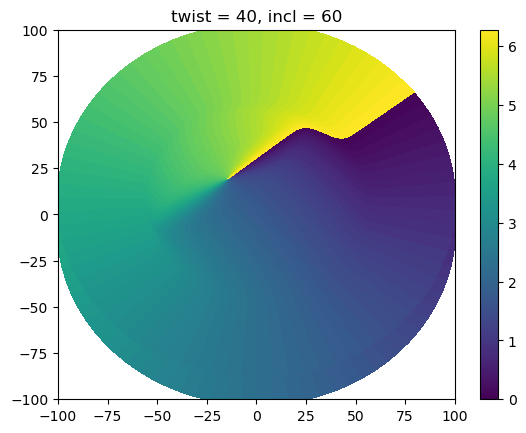

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807751e-01]
  [9.84807749e-01]
  [9.84807746e-01]
  [9.84807742e-01]
  [9.84807735e-01]
  [9.84807723e-01]
  [9.84807703e-01]
  [9.84807671e-01]
  [9.84807617e-01]
  [9.84807528e-01]
  [9.84807380e-01]
  [9.84807134e-01]
  [9.84806728e-01]
  [9.84806054e-01]
  [9.84804938e-01]
  [9.84803088e-01]
  [9.84800023e-01]
  [9.84794943e-01]
  [9.84786523e-01]
  [9.84772568e-01]
  [9.84749432e-01]
  [9.84711066e-01]
  [9.84647412e-01]
  [9.84541718e-01]
  [9.84365987e-01]
  [9.84073180e-01]
  [9.83583605e-01]
  [9.82760525e-01]
  [9.81365005e-01]
  [9.78969428e-01]
  [9.74787683e-01]
  [9.67343213e-01]
  [9.53860853e-01]
  [9.29348478e-01]
  [8.85865588e-01]
  [8.13772543e-01]
  [7.07

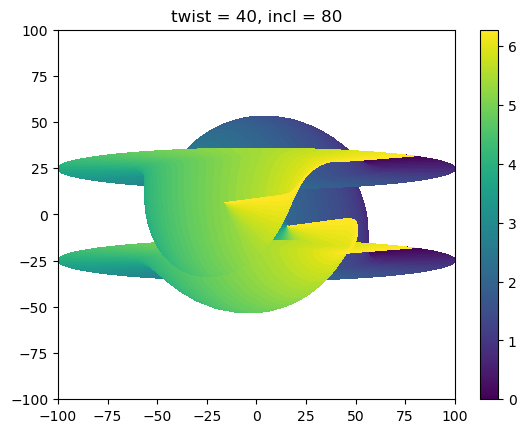

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [9.99999999e-01]
  [9.99999997e-01]
  [9.99999991e-01]
  [9.99999974e-01]
  [9.99999929e-01]
  [9.99999804e-01]
  [9.99999463e-01]
  [9.99998527e-01]
  [9.99995962e-01]
  [9.99988940e-01]
  [9.99969749e-01]
  [9.99917473e-01]
  [9.99775811e-01]
  [9.99395206e-01]
  [9.98386868e-01]
  [9.95775618e-01]
  [9.89255421e-01]
  [9.73877639e-01]
  [9.40602635e-01]
  [8.76931893e-01]
  [7.73

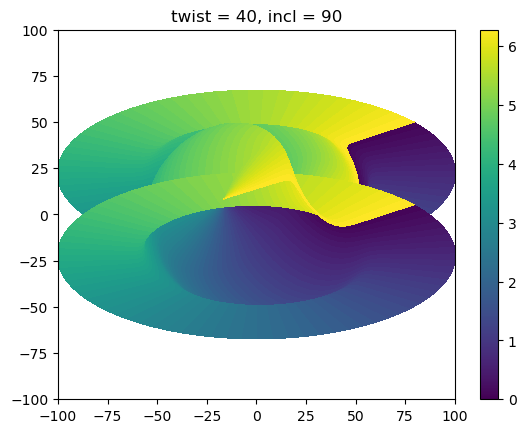

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]]]


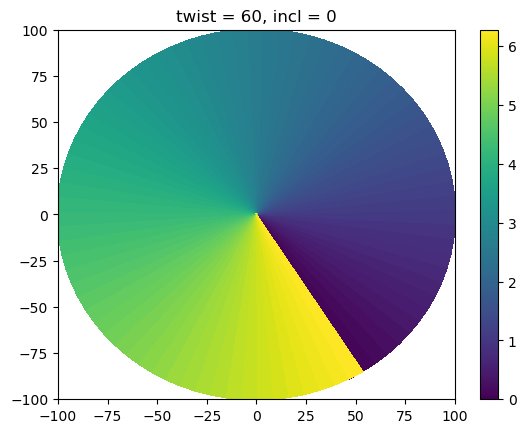

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020142e-01]
  [3.42020141e-01]
  [3.42020140e-01]
  [3.42020138e-01]
  [3.42020134e-01]
  [3.42020129e-01]
  [3.42020119e-01]
  [3.42020103e-01]
  [3.42020076e-01]
  [3.42020032e-01]
  [3.42019959e-01]
  [3.42019839e-01]
  [3.42019638e-01]
  [3.42019306e-01]
  [3.42018756e-01]
  [3.42017845e-01]
  [3.42016335e-01]
  [3.42013833e-01]
  [3.42009687e-01]
  [3.42002816e-01]
  [3.41991432e-01]
  [3.41972569e-01]
  [3.41941316e-01]
  [3.41889541e-01]
  [3.41803779e-01]
  [3.41661758e-01]
  [3.41426674e-01]
  [3.41037817e-01]
  [3.40395355e-01]
  [3.39335940e-01]
  [3.37594530e-01]
  [3.34747033e-01]
  [3.30130557e-01]
  [3.22749123e-01]
  [3.11204926e-01]
  [2.93762901e-01]
  [2.68744273e-01]
  [2.35422745e-01]
  [1.95

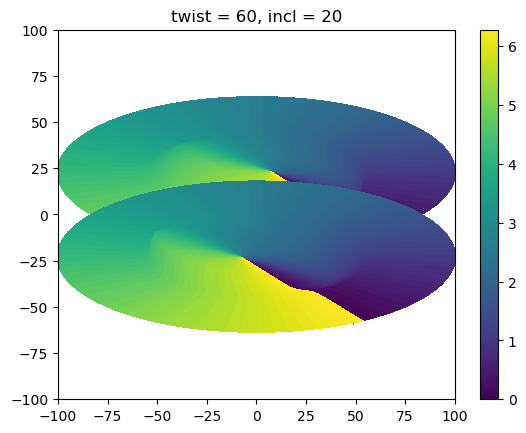

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787608e-01]
  [6.42787607e-01]
  [6.42787604e-01]
  [6.42787601e-01]
  [6.42787595e-01]
  [6.42787586e-01]
  [6.42787570e-01]
  [6.42787544e-01]
  [6.42787500e-01]
  [6.42787429e-01]
  [6.42787310e-01]
  [6.42787113e-01]
  [6.42786786e-01]
  [6.42786245e-01]
  [6.42785348e-01]
  [6.42783863e-01]
  [6.42781401e-01]
  [6.42777321e-01]
  [6.42770561e-01]
  [6.42759359e-01]
  [6.42740797e-01]
  [6.42710041e-01]
  [6.42659082e-01]
  [6.42574654e-01]
  [6.42434793e-01]
  [6.42203147e-01]
  [6.41819606e-01]
  [6.41184911e-01]
  [6.40135526e-01]
  [6.38403057e-01]
  [6.35549811e-01]
  [6.30869635e-01]
  [6.23243761e-01]
  [6.10954117e-01]
  [5.91502739e-01]
  [5.61603175e-01]
  [5.17715183e-01]
  [4.57611467e-01]
  [3.82

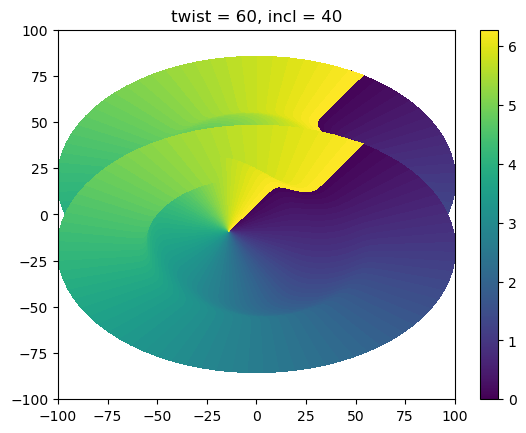

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025402e-01]
  [8.66025401e-01]
  [8.66025399e-01]
  [8.66025395e-01]
  [8.66025390e-01]
  [8.66025380e-01]
  [8.66025365e-01]
  [8.66025339e-01]
  [8.66025297e-01]
  [8.66025227e-01]
  [8.66025110e-01]
  [8.66024917e-01]
  [8.66024598e-01]
  [8.66024068e-01]
  [8.66023190e-01]
  [8.66021735e-01]
  [8.66019325e-01]
  [8.66015330e-01]
  [8.66008712e-01]
  [8.65997744e-01]
  [8.65979569e-01]
  [8.65949453e-01]
  [8.65899549e-01]
  [8.65816858e-01]
  [8.65679837e-01]
  [8.65452799e-01]
  [8.65076623e-01]
  [8.64453392e-01]
  [8.63420990e-01]
  [8.61711207e-01]
  [8.58880906e-01]
  [8.54200013e-01]
  [8.46472992e-01]
  [8.33768143e-01]
  [8.13055849e-01]
  [7.79885696e-01]
  [7.28594229e-01]
  [6.54076078e-01]
  [5.55

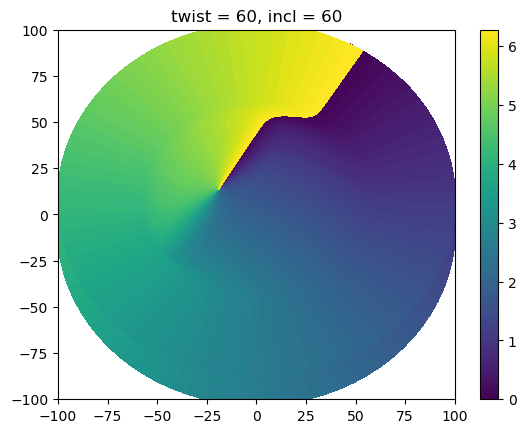

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807751e-01]
  [9.84807749e-01]
  [9.84807746e-01]
  [9.84807742e-01]
  [9.84807735e-01]
  [9.84807723e-01]
  [9.84807703e-01]
  [9.84807671e-01]
  [9.84807617e-01]
  [9.84807528e-01]
  [9.84807380e-01]
  [9.84807134e-01]
  [9.84806728e-01]
  [9.84806054e-01]
  [9.84804938e-01]
  [9.84803088e-01]
  [9.84800023e-01]
  [9.84794943e-01]
  [9.84786523e-01]
  [9.84772568e-01]
  [9.84749432e-01]
  [9.84711066e-01]
  [9.84647412e-01]
  [9.84541718e-01]
  [9.84365987e-01]
  [9.84073180e-01]
  [9.83583605e-01]
  [9.82760525e-01]
  [9.81365005e-01]
  [9.78969428e-01]
  [9.74787683e-01]
  [9.67343213e-01]
  [9.53860853e-01]
  [9.29348478e-01]
  [8.85865588e-01]
  [8.13772543e-01]
  [7.07

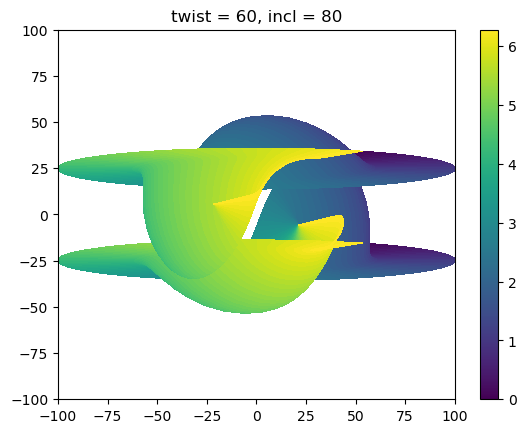

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [9.99999999e-01]
  [9.99999997e-01]
  [9.99999991e-01]
  [9.99999974e-01]
  [9.99999929e-01]
  [9.99999804e-01]
  [9.99999463e-01]
  [9.99998527e-01]
  [9.99995962e-01]
  [9.99988940e-01]
  [9.99969749e-01]
  [9.99917473e-01]
  [9.99775811e-01]
  [9.99395206e-01]
  [9.98386868e-01]
  [9.95775618e-01]
  [9.89255421e-01]
  [9.73877639e-01]
  [9.40602635e-01]
  [8.76931893e-01]
  [7.73

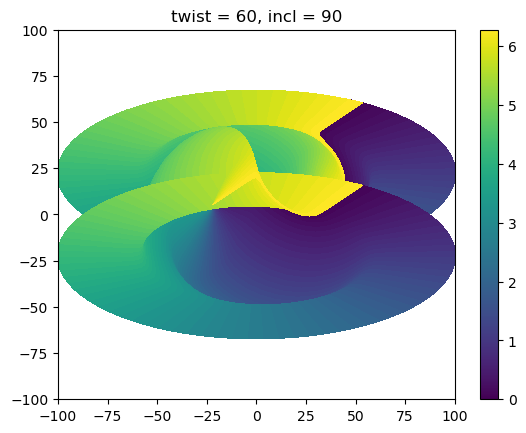

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]]]


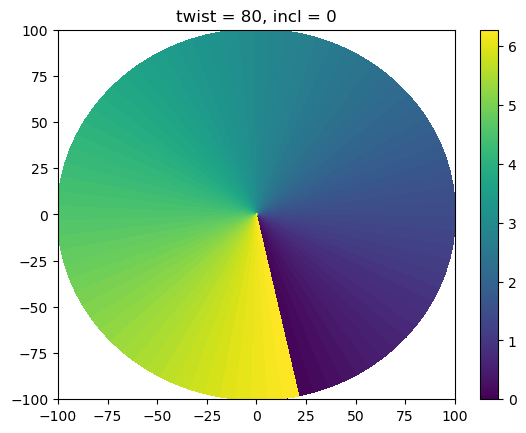

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020142e-01]
  [3.42020141e-01]
  [3.42020140e-01]
  [3.42020138e-01]
  [3.42020134e-01]
  [3.42020129e-01]
  [3.42020119e-01]
  [3.42020103e-01]
  [3.42020076e-01]
  [3.42020032e-01]
  [3.42019959e-01]
  [3.42019839e-01]
  [3.42019638e-01]
  [3.42019306e-01]
  [3.42018756e-01]
  [3.42017845e-01]
  [3.42016335e-01]
  [3.42013833e-01]
  [3.42009687e-01]
  [3.42002816e-01]
  [3.41991432e-01]
  [3.41972569e-01]
  [3.41941316e-01]
  [3.41889541e-01]
  [3.41803779e-01]
  [3.41661758e-01]
  [3.41426674e-01]
  [3.41037817e-01]
  [3.40395355e-01]
  [3.39335940e-01]
  [3.37594530e-01]
  [3.34747033e-01]
  [3.30130557e-01]
  [3.22749123e-01]
  [3.11204926e-01]
  [2.93762901e-01]
  [2.68744273e-01]
  [2.35422745e-01]
  [1.95

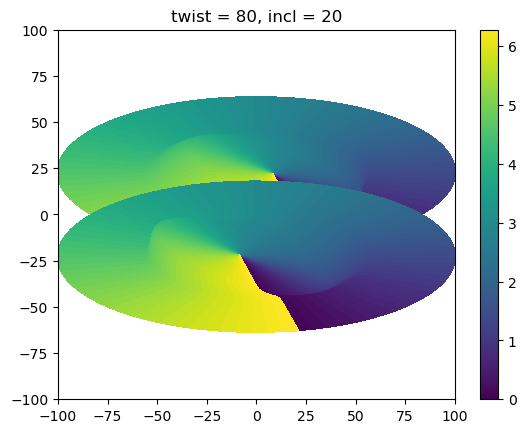

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787608e-01]
  [6.42787607e-01]
  [6.42787604e-01]
  [6.42787601e-01]
  [6.42787595e-01]
  [6.42787586e-01]
  [6.42787570e-01]
  [6.42787544e-01]
  [6.42787500e-01]
  [6.42787429e-01]
  [6.42787310e-01]
  [6.42787113e-01]
  [6.42786786e-01]
  [6.42786245e-01]
  [6.42785348e-01]
  [6.42783863e-01]
  [6.42781401e-01]
  [6.42777321e-01]
  [6.42770561e-01]
  [6.42759359e-01]
  [6.42740797e-01]
  [6.42710041e-01]
  [6.42659082e-01]
  [6.42574654e-01]
  [6.42434793e-01]
  [6.42203147e-01]
  [6.41819606e-01]
  [6.41184911e-01]
  [6.40135526e-01]
  [6.38403057e-01]
  [6.35549811e-01]
  [6.30869635e-01]
  [6.23243761e-01]
  [6.10954117e-01]
  [5.91502739e-01]
  [5.61603175e-01]
  [5.17715183e-01]
  [4.57611467e-01]
  [3.82

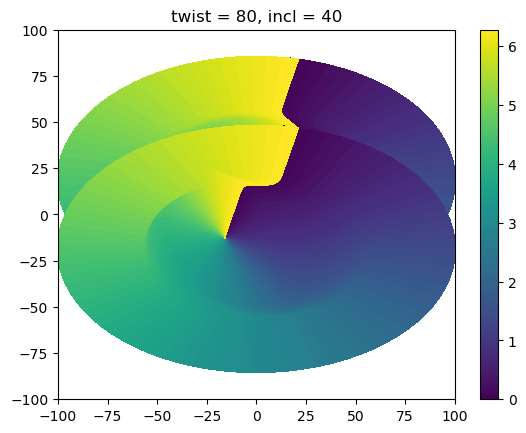

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025402e-01]
  [8.66025401e-01]
  [8.66025399e-01]
  [8.66025395e-01]
  [8.66025390e-01]
  [8.66025380e-01]
  [8.66025365e-01]
  [8.66025339e-01]
  [8.66025297e-01]
  [8.66025227e-01]
  [8.66025110e-01]
  [8.66024917e-01]
  [8.66024598e-01]
  [8.66024068e-01]
  [8.66023190e-01]
  [8.66021735e-01]
  [8.66019325e-01]
  [8.66015330e-01]
  [8.66008712e-01]
  [8.65997744e-01]
  [8.65979569e-01]
  [8.65949453e-01]
  [8.65899549e-01]
  [8.65816858e-01]
  [8.65679837e-01]
  [8.65452799e-01]
  [8.65076623e-01]
  [8.64453392e-01]
  [8.63420990e-01]
  [8.61711207e-01]
  [8.58880906e-01]
  [8.54200013e-01]
  [8.46472992e-01]
  [8.33768143e-01]
  [8.13055849e-01]
  [7.79885696e-01]
  [7.28594229e-01]
  [6.54076078e-01]
  [5.55

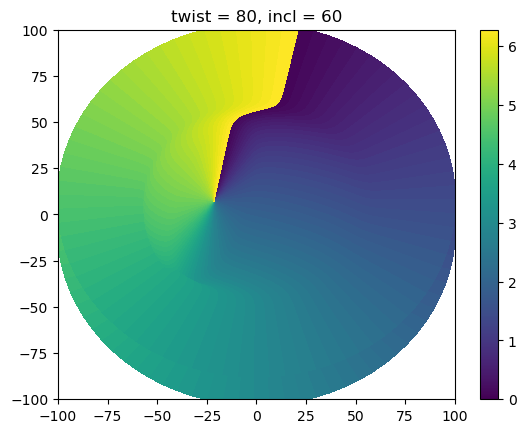

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807751e-01]
  [9.84807749e-01]
  [9.84807746e-01]
  [9.84807742e-01]
  [9.84807735e-01]
  [9.84807723e-01]
  [9.84807703e-01]
  [9.84807671e-01]
  [9.84807617e-01]
  [9.84807528e-01]
  [9.84807380e-01]
  [9.84807134e-01]
  [9.84806728e-01]
  [9.84806054e-01]
  [9.84804938e-01]
  [9.84803088e-01]
  [9.84800023e-01]
  [9.84794943e-01]
  [9.84786523e-01]
  [9.84772568e-01]
  [9.84749432e-01]
  [9.84711066e-01]
  [9.84647412e-01]
  [9.84541718e-01]
  [9.84365987e-01]
  [9.84073180e-01]
  [9.83583605e-01]
  [9.82760525e-01]
  [9.81365005e-01]
  [9.78969428e-01]
  [9.74787683e-01]
  [9.67343213e-01]
  [9.53860853e-01]
  [9.29348478e-01]
  [8.85865588e-01]
  [8.13772543e-01]
  [7.07

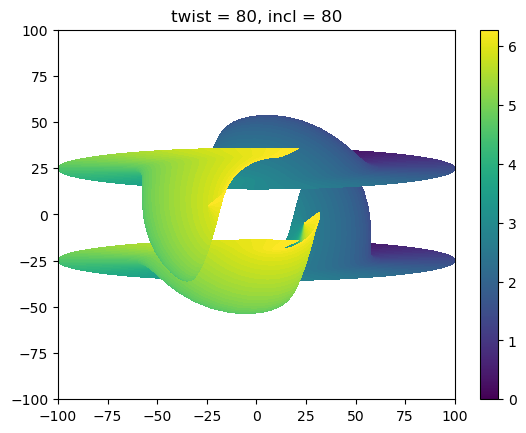

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [9.99999999e-01]
  [9.99999997e-01]
  [9.99999991e-01]
  [9.99999974e-01]
  [9.99999929e-01]
  [9.99999804e-01]
  [9.99999463e-01]
  [9.99998527e-01]
  [9.99995962e-01]
  [9.99988940e-01]
  [9.99969749e-01]
  [9.99917473e-01]
  [9.99775811e-01]
  [9.99395206e-01]
  [9.98386868e-01]
  [9.95775618e-01]
  [9.89255421e-01]
  [9.73877639e-01]
  [9.40602635e-01]
  [8.76931893e-01]
  [7.73

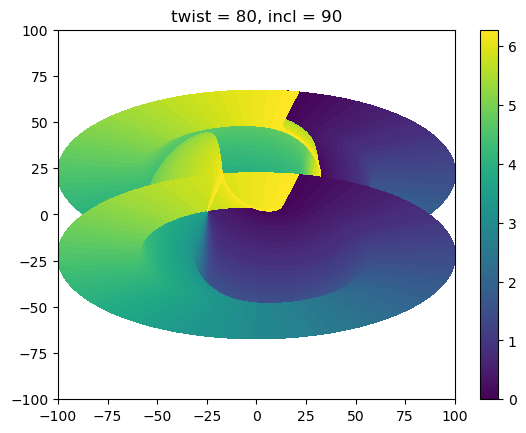

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]]]


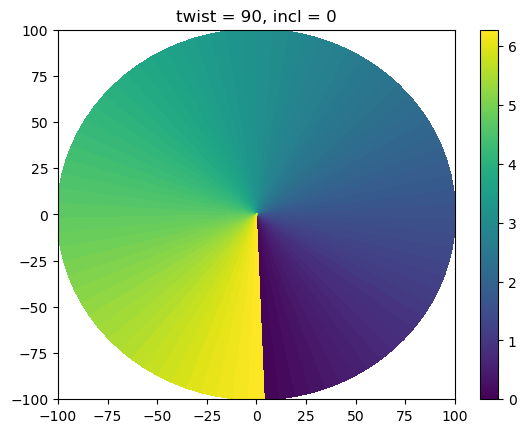

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020143e-01]
  [3.42020142e-01]
  [3.42020141e-01]
  [3.42020140e-01]
  [3.42020138e-01]
  [3.42020134e-01]
  [3.42020129e-01]
  [3.42020119e-01]
  [3.42020103e-01]
  [3.42020076e-01]
  [3.42020032e-01]
  [3.42019959e-01]
  [3.42019839e-01]
  [3.42019638e-01]
  [3.42019306e-01]
  [3.42018756e-01]
  [3.42017845e-01]
  [3.42016335e-01]
  [3.42013833e-01]
  [3.42009687e-01]
  [3.42002816e-01]
  [3.41991432e-01]
  [3.41972569e-01]
  [3.41941316e-01]
  [3.41889541e-01]
  [3.41803779e-01]
  [3.41661758e-01]
  [3.41426674e-01]
  [3.41037817e-01]
  [3.40395355e-01]
  [3.39335940e-01]
  [3.37594530e-01]
  [3.34747033e-01]
  [3.30130557e-01]
  [3.22749123e-01]
  [3.11204926e-01]
  [2.93762901e-01]
  [2.68744273e-01]
  [2.35422745e-01]
  [1.95

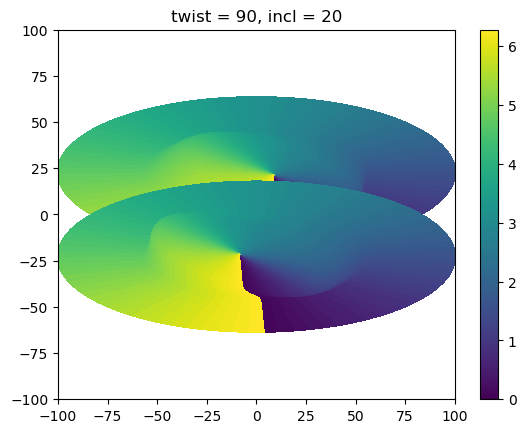

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787610e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787609e-01]
  [6.42787608e-01]
  [6.42787607e-01]
  [6.42787604e-01]
  [6.42787601e-01]
  [6.42787595e-01]
  [6.42787586e-01]
  [6.42787570e-01]
  [6.42787544e-01]
  [6.42787500e-01]
  [6.42787429e-01]
  [6.42787310e-01]
  [6.42787113e-01]
  [6.42786786e-01]
  [6.42786245e-01]
  [6.42785348e-01]
  [6.42783863e-01]
  [6.42781401e-01]
  [6.42777321e-01]
  [6.42770561e-01]
  [6.42759359e-01]
  [6.42740797e-01]
  [6.42710041e-01]
  [6.42659082e-01]
  [6.42574654e-01]
  [6.42434793e-01]
  [6.42203147e-01]
  [6.41819606e-01]
  [6.41184911e-01]
  [6.40135526e-01]
  [6.38403057e-01]
  [6.35549811e-01]
  [6.30869635e-01]
  [6.23243761e-01]
  [6.10954117e-01]
  [5.91502739e-01]
  [5.61603175e-01]
  [5.17715183e-01]
  [4.57611467e-01]
  [3.82

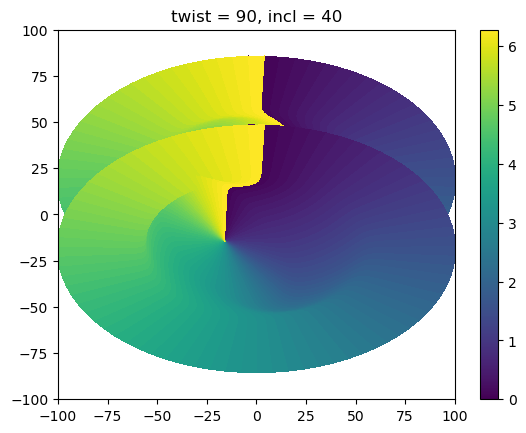

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025404e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025403e-01]
  [8.66025402e-01]
  [8.66025401e-01]
  [8.66025399e-01]
  [8.66025395e-01]
  [8.66025390e-01]
  [8.66025380e-01]
  [8.66025365e-01]
  [8.66025339e-01]
  [8.66025297e-01]
  [8.66025227e-01]
  [8.66025110e-01]
  [8.66024917e-01]
  [8.66024598e-01]
  [8.66024068e-01]
  [8.66023190e-01]
  [8.66021735e-01]
  [8.66019325e-01]
  [8.66015330e-01]
  [8.66008712e-01]
  [8.65997744e-01]
  [8.65979569e-01]
  [8.65949453e-01]
  [8.65899549e-01]
  [8.65816858e-01]
  [8.65679837e-01]
  [8.65452799e-01]
  [8.65076623e-01]
  [8.64453392e-01]
  [8.63420990e-01]
  [8.61711207e-01]
  [8.58880906e-01]
  [8.54200013e-01]
  [8.46472992e-01]
  [8.33768143e-01]
  [8.13055849e-01]
  [7.79885696e-01]
  [7.28594229e-01]
  [6.54076078e-01]
  [5.55

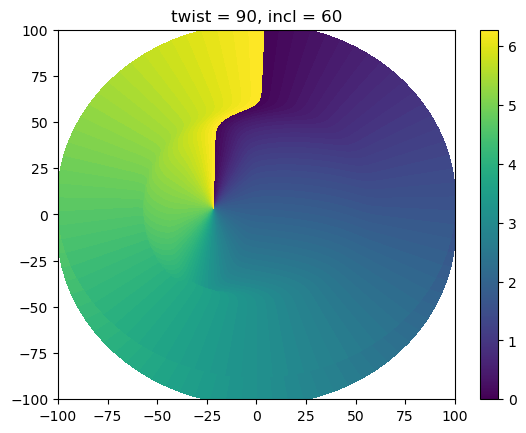

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807753e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807752e-01]
  [9.84807751e-01]
  [9.84807749e-01]
  [9.84807746e-01]
  [9.84807742e-01]
  [9.84807735e-01]
  [9.84807723e-01]
  [9.84807703e-01]
  [9.84807671e-01]
  [9.84807617e-01]
  [9.84807528e-01]
  [9.84807380e-01]
  [9.84807134e-01]
  [9.84806728e-01]
  [9.84806054e-01]
  [9.84804938e-01]
  [9.84803088e-01]
  [9.84800023e-01]
  [9.84794943e-01]
  [9.84786523e-01]
  [9.84772568e-01]
  [9.84749432e-01]
  [9.84711066e-01]
  [9.84647412e-01]
  [9.84541718e-01]
  [9.84365987e-01]
  [9.84073180e-01]
  [9.83583605e-01]
  [9.82760525e-01]
  [9.81365005e-01]
  [9.78969428e-01]
  [9.74787683e-01]
  [9.67343213e-01]
  [9.53860853e-01]
  [9.29348478e-01]
  [8.85865588e-01]
  [8.13772543e-01]
  [7.07

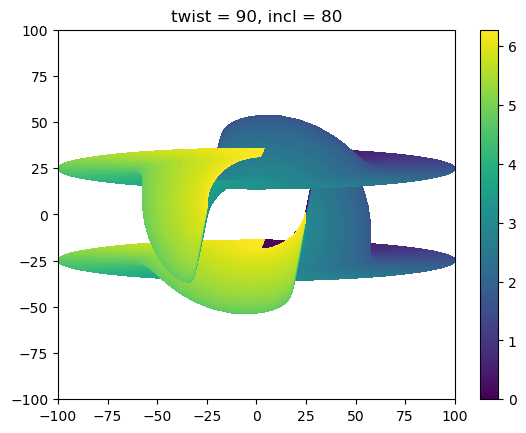

warp.shape(100,)
warp.shape(1, 100, 1)
cosw shape (1, 100, 1)
[[[1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [1.00000000e+00]
  [9.99999999e-01]
  [9.99999997e-01]
  [9.99999991e-01]
  [9.99999974e-01]
  [9.99999929e-01]
  [9.99999804e-01]
  [9.99999463e-01]
  [9.99998527e-01]
  [9.99995962e-01]
  [9.99988940e-01]
  [9.99969749e-01]
  [9.99917473e-01]
  [9.99775811e-01]
  [9.99395206e-01]
  [9.98386868e-01]
  [9.95775618e-01]
  [9.89255421e-01]
  [9.73877639e-01]
  [9.40602635e-01]
  [8.76931893e-01]
  [7.73

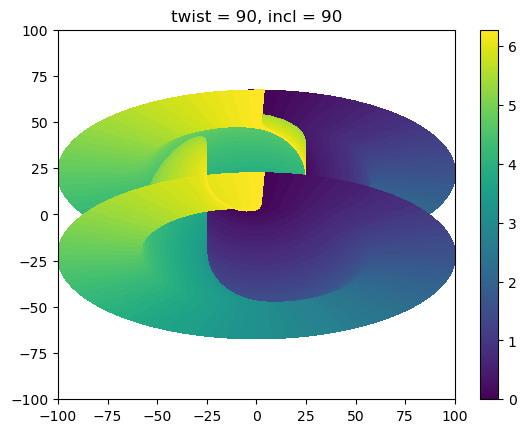

In [223]:
az_list = [0,20,40,60,80,90]
incl_list = [0,20,40,60,80,90]

for i in range(len(az_list)):
    for j in range(len(incl_list)):
        twist = w_func_sky(r0, dr, az_list[i], az_list[i], r)
        warp = w_func_sky(r0, dr, incl_list[j], 0, r)
        X_t, Y_t, Z_t = matrix_twist(X, Y, Z, warp, twist, incl_list[j], azi, 0)

        plt.pcolor(X_t[:,:,0], Y_t[:,:,0], Phi[:,:,0])
        plt.pcolor(X_t[:,:,-1], Y_t[:,:,-1], Phi[:,:,-1])
        #plt.plot(X_t[:,:,0], Y_t[:,:,0])
        plt.xlim(-100,100)
        plt.ylim(-100,100)

        plt.title("twist = {}, incl = {}".format(az_list[i], incl_list[j]))

        plt.colorbar()
        plt.show()